In [ ]:
import cv2
from cv2 import imwrite

input_file="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing video/alligator/image_processing8_alligator.mp4"

vid=cv2.VideoCapture(input_file)
x=0
if not vid.isOpened():
        print("error")
else:
      while True:
   
        rec,frame= vid.read()

        if not rec:
            print("video frame can't process")
            break
        if
        cv2.imshow("frame",frame)
        imwrite(f"C:\Users\user\Documents\RUSL\2nd Year\ICT2403-Graphics and Image Processing\Lab\image processing project\image processing video\alligator\extracted/frame_{x}.png",frame)
            
        x+=1
        if cv2.waitKey(40) == ord('q'):
            break

vid.release()
cv2.destroyAllWindows()

In [23]:

import cv2
import matplotlib.pyplot as plt
import numpy as np
out_path="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/pothole/pothole 1/enhanced/"
def estimate_blur(image, threshold=200):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    variance = laplacian.var()
    return variance, variance < threshold  

def estimate_noise(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.5)
    diff = cv2.absdiff(image, blurred)
    noise_level = np.mean(diff)
    return noise_level, noise_level > 10  

def estimate_contrast(image):
    std_dev = np.std(image)
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    non_zero = np.where(hist > 0)[0]
    if len(non_zero) > 0:
        spread = non_zero[-1] - non_zero[0]
    else:
        spread = 0
    
    low_contrast = (std_dev < 40) or (spread < 150)
    return std_dev, spread, low_contrast

def dynamic_preprocess(image):
    
    processed = image.copy()
    steps_applied = []
    
    blur_value, is_blurry = estimate_blur(image)

    
    if is_blurry:
        kernel = np.array([[-1,-1,-1],
                          [-1, 9,-1],
                          [-1,-1,-1]])
        processed = cv2.filter2D(processed, -1, kernel)
        steps_applied.append("Sharpening")

    
    noise_level, is_noisy = estimate_noise(processed)


    if is_noisy:
  
        if noise_level > 20:
            kernel_size = (7, 7)
        elif noise_level > 15:
            kernel_size = (5, 5)
        else:
            kernel_size = (3, 3)
        
        
        processed = cv2.GaussianBlur(processed, kernel_size, 1.0)
        steps_applied.append(f"Gaussian blur {kernel_size}")

    
    
    std_dev, spread, low_contrast = estimate_contrast(processed)

    
    if low_contrast:
        if is_noisy or is_blurry:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            processed = clahe.apply(processed)
            steps_applied.append("CLAHE equalization")
        else:
            processed = cv2.equalizeHist(processed)
            steps_applied.append("Global histogram equalization")
        
    
    return processed, steps_applied


    

count = 1
while True:
    path = "C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/pothole/pothole 1/extracted/"+ str(count) +".jpg"
    img = cv2.imread(path, 0)
    
    
    if img is None:
        print("No frame")
        break
    else:
        processed_img, steps = dynamic_preprocess(img)
        
        cv2.imshow("processed",processed_img)
        cv2.imshow("original",img)
        save_path = out_path + f"enhanced_{count}.jpg"
        cv2.imwrite(save_path, processed_img)
        if cv2.waitKey(110)==ord('q'):
            break
        
    count = count + 1

cv2.destroyAllWindows()

No frame


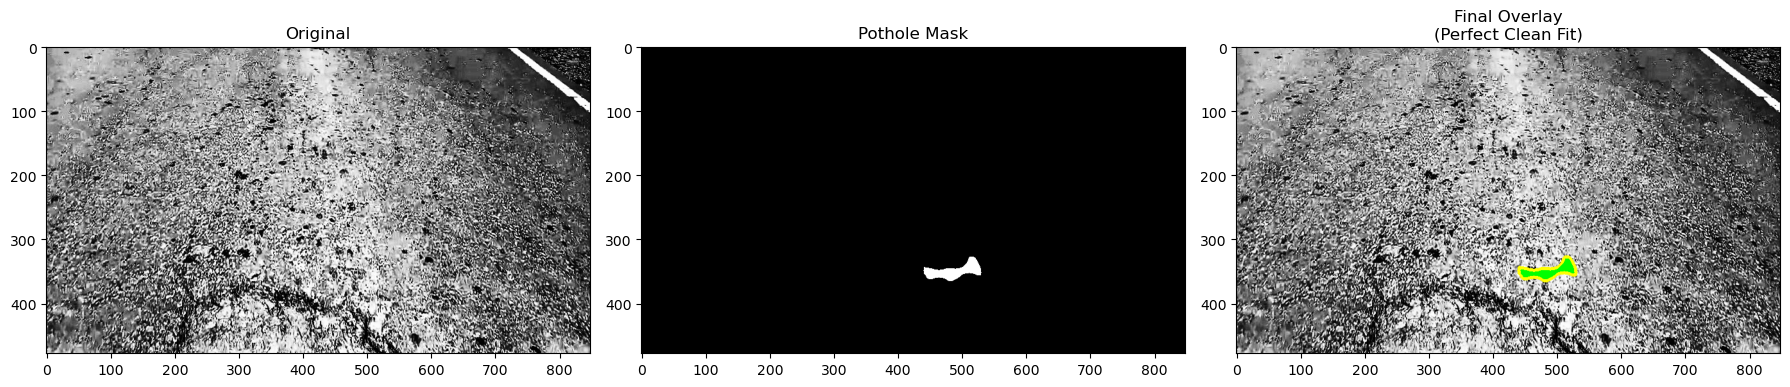

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segment_pothole_fused(image):
    h, w = image.shape

   
    blurred = cv2.GaussianBlur(image, (21, 21), 0)

    
    thresh = cv2.adaptiveThreshold(
        blurred, 255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 
        101, 12 
    )

    
    kernel_small = np.ones((5, 5), np.uint8)
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_small, iterations=2)
    
    
    contours, _ = cv2.findContours(opened, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    fat_canvas = np.zeros_like(image)
    
    for cnt in contours:
        length = cv2.arcLength(cnt, closed=False)
        if length > 50:
            x, y, bw, bh = cv2.boundingRect(cnt)
            cx, cy = x + bw / 2, y + bh / 2
            
            if (w * 0.2 < cx < w * 0.8) and (h * 0.15 < cy < h * 0.75):
                cv2.drawContours(fat_canvas, [cnt], -1, 255, thickness=40)

    temp_mask = np.zeros_like(image)
    
    
    fill_contours, _ = cv2.findContours(fat_canvas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if fill_contours:
        
        main_blob = max(fill_contours, key=cv2.contourArea)
        cv2.drawContours(fat_canvas, [main_blob], -1, 255, -1)

        
        kernel_shrink = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (41, 41))
        temp_mask = cv2.erode(fat_canvas, kernel_shrink, iterations=1)

    
    final_mask = np.zeros_like(image)
    final_contours, _ = cv2.findContours(temp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if final_contours:
      
        true_main_blob = max(final_contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [true_main_blob], -1, 255, -1)

    return final_mask


path = "11.jpg" 
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Path incorrect.")
else:
    mask = segment_pothole_fused(img)
    
 
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    overlay[mask > 0] = [0, 255, 0] 
    
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 255), 3)

   
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original")
    axes[1].imshow(mask, cmap='gray', vmin=0, vmax=255); axes[1].set_title("Pothole Mask")
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Final Overlay\n(Perfect Clean Fit)")
    
    plt.tight_layout(); plt.show()

In [5]:
total_frames = 11  
output_name = "pothole_analysis3.mp4"
fps = 3



first_frame = cv2.imread("1.jpg") 
h, w, _ = first_frame.shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_name, fourcc, fps, (w, h))



for i in range(1, total_frames + 1):
    filename = f"{i}.jpg"
    frame = cv2.imread(filename)
    
    if frame is None:
        print("Error")
        break

    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mask = segment_pothole_fused(gray) 
    
    
    overlay = frame.copy()
    overlay[mask > 0] = [0, 255, 0]
    
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        main_cnt = max(contours, key=cv2.contourArea)
        
      
        cv2.drawContours(overlay, [main_cnt], -1, (0, 255, 255), 2)
        
       
        x, y, bw, bh = cv2.boundingRect(main_cnt)
        cv2.rectangle(overlay, (x, y), (x + bw, y + bh), (255, 0, 0), 3)
        
     
        cv2.putText(overlay, "ANALYZING...", (20, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

 
    out.write(overlay)


out.release()
print(f"Video saved as {output_name}")

Video saved as pothole_analysis3.mp4


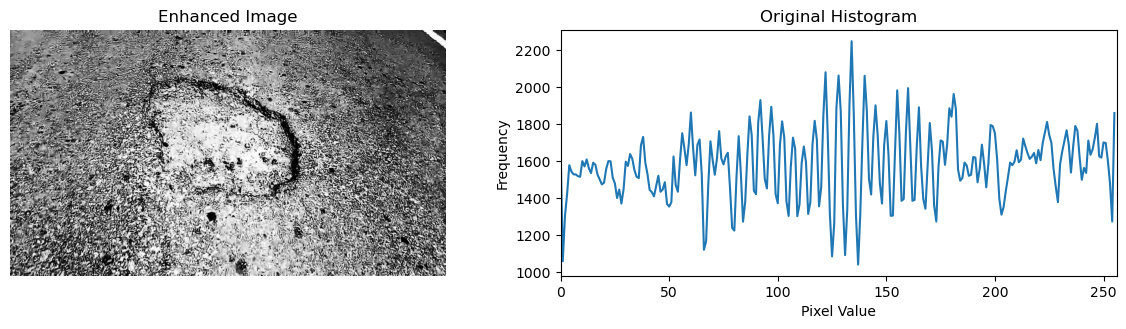

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def plot_histogram(image, title):
    """Plot histogram of the given image."""
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
    
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.plot(histogram)
    plt.xlim([0, 256])


image = cv2.imread('5.jpg', 0)  # change path if needed

if image is None:
    raise ValueError("Image not found. Check the file path.")



plt.figure(figsize=(12, 6))


plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Enhanced Image")
plt.axis('off')


plt.subplot(2, 2, 2)
plot_histogram(image, "Original Histogram")



plt.tight_layout()
plt.show()
